In [31]:
import numpy as np
import sklearn as sk
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error


import matplotlib.pyplot as plt

from utils import gen_data

## Generating Data

In [32]:
X, y = gen_data()

print(X[:5], '\n', y[:5])

[[142]
 [219]
 [132]
 [ 54]
 [146]] 
 [118587 218242 125672  13339 137882]


## Plotting Data

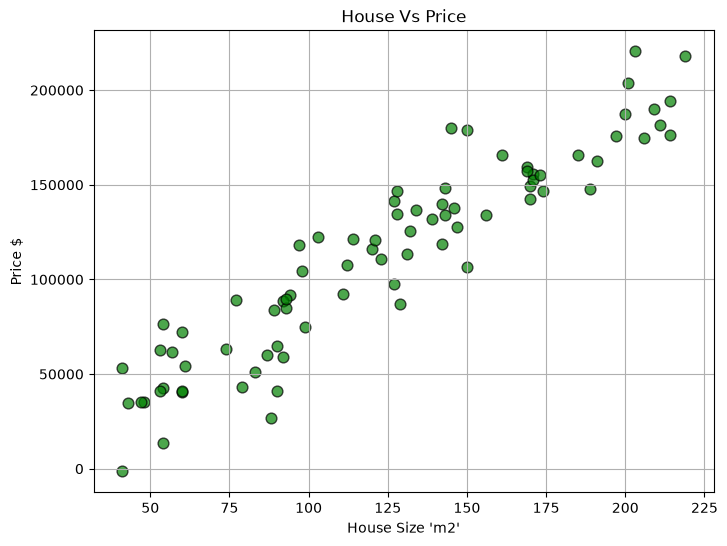

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='green', s=60, alpha=0.7, edgecolors='black')

plt.title('House Vs Price')

plt.xlabel("House Size 'm2'")
plt.ylabel("Price $")

plt.grid(True)

plt.show()

## Splting data

In [34]:
X_train, _x, y_train, _y = train_test_split(X, y, test_size=0.3, random_state=42)
X_cv, X_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.3, random_state=41)
print(_x.shape)
print(X_train.shape, X_cv.shape, X_test.shape)

(24, 1)
(56, 1) (16, 1) (8, 1)


## Scaling Data

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_cv_scaled = scaler.transform(X_cv)
x_test_scaled = scaler.transform(X_test)

In [51]:
poly = PolynomialFeatures(degree=2)
x_train_scaled_mapped = poly.fit_transform(x_train_scaled)
print(x_train_scaled_mapped)

[[ 1.00000000e+00  3.51839548e-01  1.23791068e-01]
 [ 1.00000000e+00  2.71582869e-01  7.37572549e-02]
 [ 1.00000000e+00  1.53562556e+00  2.35814587e+00]
 [ 1.00000000e+00  4.12032058e-01  1.69770416e-01]
 [ 1.00000000e+00  1.19453468e+00  1.42691310e+00]
 [ 1.00000000e+00  8.93572132e-01  7.98471155e-01]
 [ 1.00000000e+00 -1.65457743e+00  2.73762646e+00]
 [ 1.00000000e+00  4.12032058e-01  1.69770416e-01]
 [ 1.00000000e+00  2.51518700e-01  6.32616562e-02]
 [ 1.00000000e+00 -7.51689789e-01  5.65037538e-01]
 [ 1.00000000e+00  3.08128321e-02  9.49430624e-04]
 [ 1.00000000e+00 -4.94438469e-02  2.44469400e-03]
 [ 1.00000000e+00 -7.31625619e-01  5.35276046e-01]
 [ 1.00000000e+00 -6.51368940e-01  4.24281496e-01]
 [ 1.00000000e+00  8.33379623e-01  6.94521595e-01]
 [ 1.00000000e+00  2.71582869e-01  7.37572549e-02]
 [ 1.00000000e+00 -1.51412824e+00  2.29258433e+00]
 [ 1.00000000e+00 -1.51412824e+00  2.29258433e+00]
 [ 1.00000000e+00 -7.51689789e-01  5.65037538e-01]
 [ 1.00000000e+00 -7.91818128e-

In [52]:
model = Ridge(alpha=0.001)
model.fit(x_train_scaled_mapped, y_train)
yhat_train = model.predict(x_train_scaled_mapped)

print(model.score(x_train_scaled_mapped, y_train))

0.8856130651720874


In [38]:
mse_train = root_mean_squared_error(yhat_train, y_train)
print(mse_train)

16452.191560322008


In [53]:
x_cv_scaled_mapped = poly.transform(x_cv_scaled)
yhat_cv = model.predict(x_cv_scaled_mapped)
print(model.score(x_cv_scaled_mapped, y_cv))

0.8603024865659217


In [40]:
mse_cv = root_mean_squared_error(yhat_cv, y_cv)
print(mse_cv)

21060.460083249392


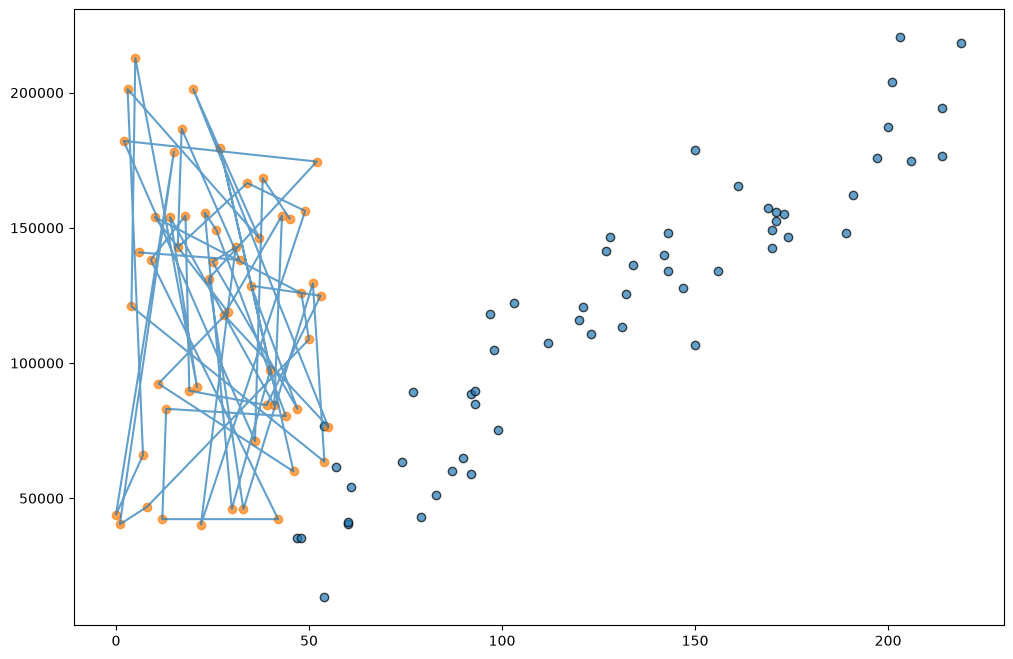

In [50]:
idx = np.argsort(X_train[:,0])

plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, alpha=0.7, edgecolors='black')
plt.scatter(idx, yhat_train, alpha=0.7)
plt.plot(idx, yhat_train, alpha=0.7)
plt.show()